# Pima Indians Diabetes Diagnostic System
### Comprehensive Data Queries, Exploratory Data Analysis, Classification Pipeline, and Serialization

**Objective:**
Predict whether a patient has diabetes (Outcome = 1) or is healthy (Outcome = 0) based on clinical measurements. 

**Key Industry & Preprocessing Requirements Covered:**
1. **Hidden Missing Values Handling:** Identifying invalid `0` values in clinical columns (like Glucose, BloodPressure, Insulin, and BMI) and handling them using leak-free `SimpleImputer` pipeline steps.
2. **Strict Preprocessing Isolation:** Separating train-test splits before running any scaling or imputation to prevent data leakage.
3. **Cost-Sensitive Metrics:** Evaluating models using Confusion Matrices, Classification Reports (Precision, Recall, F1), and ROC-AUC curves, focusing on reducing False Negatives (Recall).
4. **Ensemble Models & Tuning:** Comparing Logistic Regression, Random Forest, and XGBoost Classifiers, followed by RandomizedSearchCV hyperparameter tuning.

## Initial Environment Setup & Data Import
First, we import the core packages, setup plotting parameters, and download the Pima Indians Diabetes dataset from Kaggle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Configure plotting styles for classroom and professional review
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.facecolor': '#FFFFFF',
    'axes.facecolor': '#FFFFFF',
    'savefig.facecolor': '#FFFFFF',
    'text.color': '#212529',
    'axes.labelcolor': '#212529',
    'font.family': 'sans-serif'
})

# Load Pima Indians Diabetes dataset directly from a public repository
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
df = pd.read_csv(url)
print("Diabetes Data shape:", df.shape)

Diabetes Data shape: (768, 9)


## Part 1: Pandas Data Queries & Quantitative Analysis
Following the structure of `Data_Analysis.ipynb`, we query and aggregate the clinical log to answer key medical and diagnostic questions.

### Question 1: What is the total count and proportion of diabetic vs. healthy patients?

In [2]:
counts = df['Outcome'].value_counts()
pcts = df['Outcome'].value_counts(normalize=True) * 100

print("Quantitative Class Breakdown:")
for outcome, count in counts.items():
    label = "Diabetic" if outcome == 1 else "Healthy"
    print(f" - {label} (Outcome {outcome}): {count} records | {pcts[outcome]:.2f}%")

Quantitative Class Breakdown:
 - Healthy (Outcome 0): 500 records | 65.10%
 - Diabetic (Outcome 1): 268 records | 34.90%


### Question 2: What are the average clinical measurements (Glucose, BMI, Age, Insulin) grouped by Outcome?

In [3]:
display(df.groupby('Outcome')[['Glucose', 'BMI', 'Age', 'Insulin', 'BloodPressure']].mean())

,Glucose,BMI,Age,Insulin,BloodPressure
Outcome,,,,,
0,109.980000,30.304200,31.190000,68.792000,68.184000
1,141.257463,35.142537,37.067164,100.335821,70.824627


### Question 3: Find the 10 oldest patients in the dataset. Are they mostly diabetic or healthy?

In [4]:
oldest_patients = df.sort_values(by='Age', ascending=False).head(10)
display(oldest_patients[['Age', 'Glucose', 'BMI', 'Outcome']])

,Age,Glucose,BMI,Outcome
459,81,134,25.9,0
453,72,119,19.6,0
666,70,145,32.5,1
123,69,132,26.8,0
684,69,136,0.0,0
674,68,91,35.6,0
363,67,146,38.5,1
489,67,194,26.1,0
537,67,57,21.7,0
495,66,166,26.6,0


### Question 4: Filter all patients with a BMI greater than 35 and Age greater than 50. What is their diabetes rate?

In [5]:
high_risk = df[(df['BMI'] > 35) & (df['Age'] > 50)]
total_high = len(high_risk)
diabetic_high = high_risk['Outcome'].sum()

print(f"Total high-risk patients (BMI > 35 & Age > 50): {total_high}")
print(f"Diabetic patients in this group: {diabetic_high} (Diabetes rate: {(diabetic_high/total_high)*100:.2f}%)")

Total high-risk patients (BMI > 35 & Age > 50): 23
Diabetic patients in this group: 14 (Diabetes rate: 60.87%)


### Question 5: Identifying Zeros as Missing Values
In clinical logs, missing values are sometimes recorded as `0` instead of `NaN`. Identify how many zero values exist in key clinical columns where a zero is biologically impossible (Glucose, BloodPressure, SkinThickness, Insulin, and BMI).

In [6]:
impossible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Count of invalid zero values per column:")
for col in impossible_cols:
    zeros = (df[col] == 0).sum()
    print(f" - {col}: {zeros} zeros ({(zeros / len(df))*100:.2f}% of data)")

Count of invalid zero values per column:
 - Glucose: 5 zeros (0.65% of data)
 - BloodPressure: 35 zeros (4.56% of data)
 - SkinThickness: 227 zeros (29.56% of data)
 - Insulin: 374 zeros (48.70% of data)
 - BMI: 11 zeros (1.43% of data)


### Question 6: What features show the highest correlation with the Outcome target?

In [7]:
correlations = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
print("Feature correlations with Outcome:")
print(correlations)

Feature correlations with Outcome:
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


## Part 2: Visual EDA using Matplotlib
Following the structure of the `Exploratory_Data_Analysis_Laptop` notebook, we construct Matplotlib charts to visualize distributions, relationships, and outliers.

### 1. Line Chart: Diabetes Rate by Age Groups

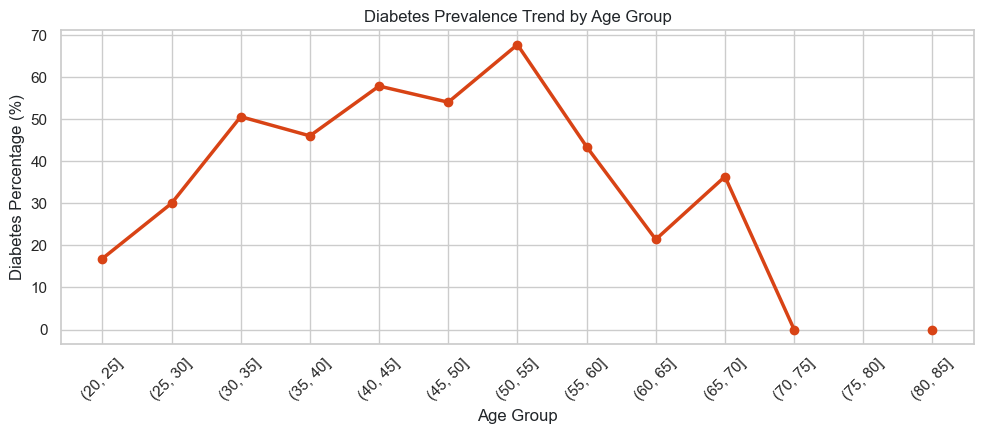

In [8]:
# Bin Age into groups of 5 years
df['AgeGroup'] = pd.cut(df['Age'], bins=range(20, 90, 5))
age_group_stats = df.groupby('AgeGroup', observed=False)['Outcome'].mean() * 100

plt.figure(figsize=(10, 4.5))
plt.plot(age_group_stats.index.astype(str), age_group_stats.values, color='#D84315', marker='o', linewidth=2.5)
plt.xlabel('Age Group')
plt.ylabel('Diabetes Percentage (%)')
plt.title('Diabetes Prevalence Trend by Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Bar Charts (Vertical & Horizontal): Mean Glucose Levels by Outcome

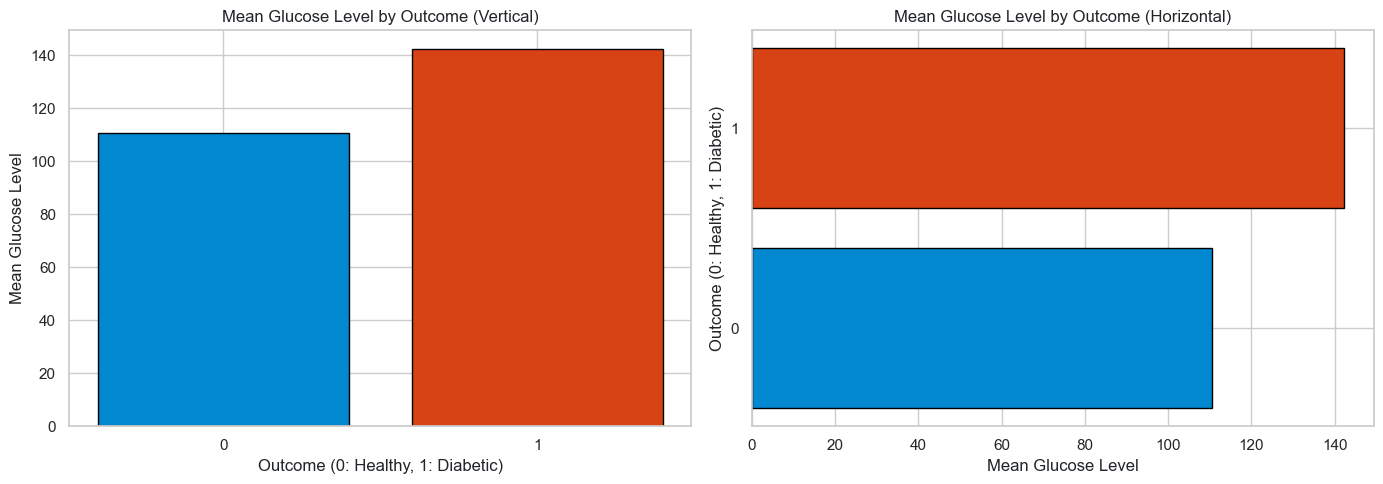

In [9]:
# Filtering out invalid zeros for accurate mean calculation
valid_glucose = df[df['Glucose'] > 0]
mean_glucose = valid_glucose.groupby('Outcome')['Glucose'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vertical Bar Chart
axes[0].bar(mean_glucose.index.astype(str), mean_glucose.values, color=['#0288D1', '#D84315'], edgecolor='black')
axes[0].set_xlabel('Outcome (0: Healthy, 1: Diabetic)')
axes[0].set_ylabel('Mean Glucose Level')
axes[0].set_title('Mean Glucose Level by Outcome (Vertical)')

# Horizontal Bar Chart
axes[1].barh(mean_glucose.index.astype(str), mean_glucose.values, color=['#0288D1', '#D84315'], edgecolor='black')
axes[1].set_ylabel('Outcome (0: Healthy, 1: Diabetic)')
axes[1].set_xlabel('Mean Glucose Level')
axes[1].set_title('Mean Glucose Level by Outcome (Horizontal)')

plt.tight_layout()
plt.show()

### 3. Histogram: Distribution of BMI comparing classes

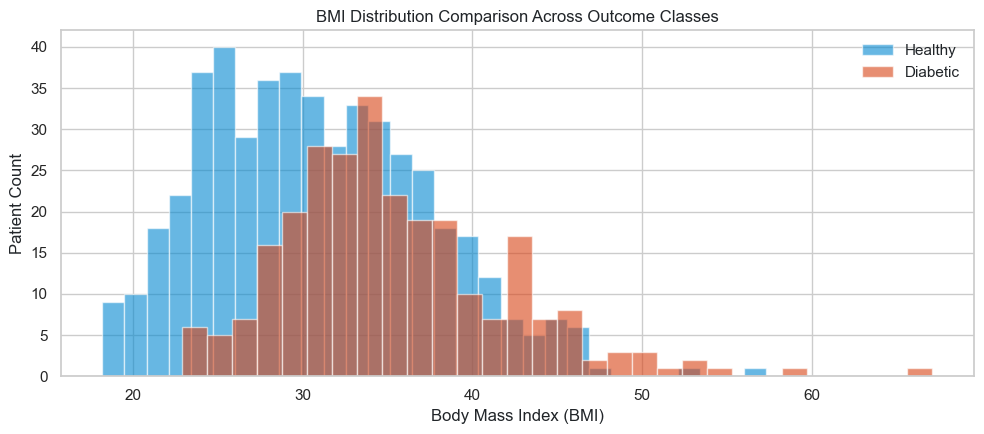

In [10]:
valid_bmi = df[df['BMI'] > 0]

plt.figure(figsize=(10, 4.5))
plt.hist(valid_bmi[valid_bmi['Outcome'] == 0]['BMI'], bins=30, alpha=0.6, label='Healthy', color='#0288D1', edgecolor='white')
plt.hist(valid_bmi[valid_bmi['Outcome'] == 1]['BMI'], bins=30, alpha=0.6, label='Diabetic', color='#D84315', edgecolor='white')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Patient Count')
plt.title('BMI Distribution Comparison Across Outcome Classes')
plt.legend()
plt.tight_layout()
plt.show()

### 4. Scatter Plot: Glucose vs. Insulin levels

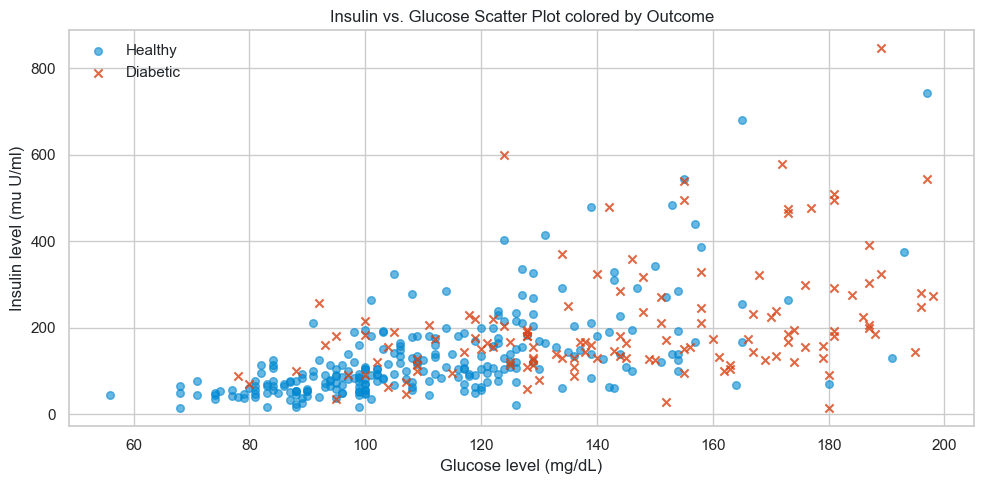

In [11]:
# Filter out invalid zero inputs
valid_data = df[(df['Glucose'] > 0) & (df['Insulin'] > 0)]

plt.figure(figsize=(10, 5))
plt.scatter(valid_data[valid_data['Outcome'] == 0]['Glucose'], valid_data[valid_data['Outcome'] == 0]['Insulin'], alpha=0.6, label='Healthy', color='#0288D1', s=30)
plt.scatter(valid_data[valid_data['Outcome'] == 1]['Glucose'], valid_data[valid_data['Outcome'] == 1]['Insulin'], alpha=0.8, label='Diabetic', color='#D84315', s=35, marker='x')
plt.xlabel('Glucose level (mg/dL)')
plt.ylabel('Insulin level (mu U/ml)')
plt.title('Insulin vs. Glucose Scatter Plot colored by Outcome')
plt.legend()
plt.tight_layout()
plt.show()

### 5. Pie Chart: Proportions of Diabetic vs. Healthy Patients

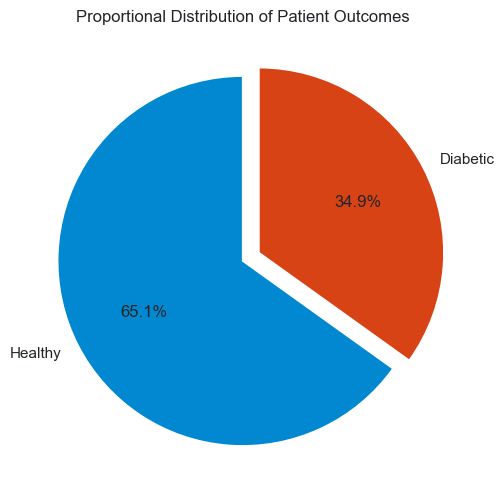

In [12]:
plt.figure(figsize=(6, 6))
plt.pie(df['Outcome'].value_counts(), labels=['Healthy', 'Diabetic'], autopct='%1.1f%%', 
        explode=[0, 0.1], colors=['#0288D1', '#D84315'], startangle=90)
plt.title('Proportional Distribution of Patient Outcomes')
plt.show()

### 6. Box Plot: Range Comparison of Insulin Levels

C:\Users\user\AppData\Local\Temp\ipykernel_215864\410279200.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


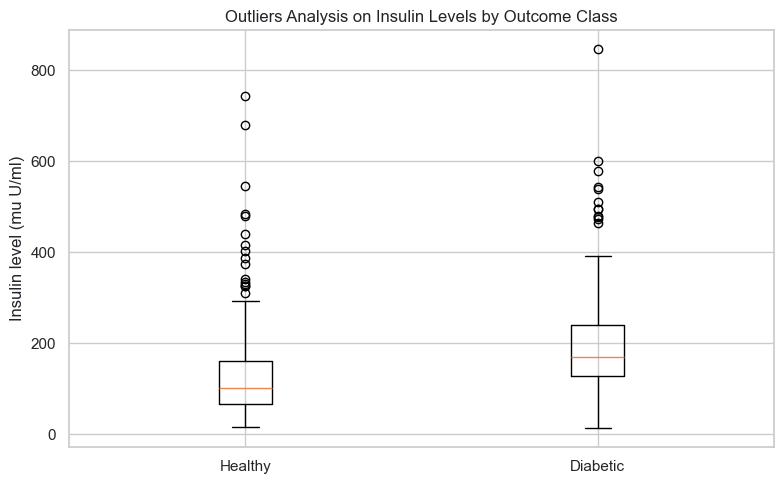

In [13]:
valid_insulin = df[df['Insulin'] > 0]

plt.figure(figsize=(8, 5))
plt.boxplot(
    [valid_insulin[valid_insulin['Outcome'] == 0]['Insulin'], valid_insulin[valid_insulin['Outcome'] == 1]['Insulin']],
    labels=['Healthy', 'Diabetic']
)
plt.ylabel('Insulin level (mu U/ml)')
plt.title('Outliers Analysis on Insulin Levels by Outcome Class')
plt.tight_layout()
plt.show()

## Part 3: Visual EDA using Seaborn
We recreate visual distributions and relationships using the advanced styling features of Seaborn.

### 1. Countplot: Visualizing Outcome Classes

C:\Users\user\AppData\Local\Temp\ipykernel_215864\3202631562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


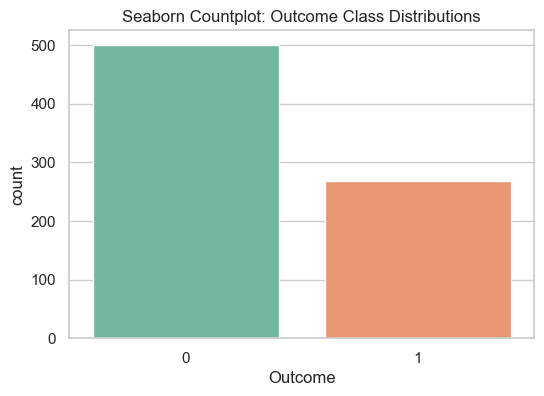

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Seaborn Countplot: Outcome Class Distributions')
plt.show()

### 2. Barplot: Mean Insulin levels across Age groups

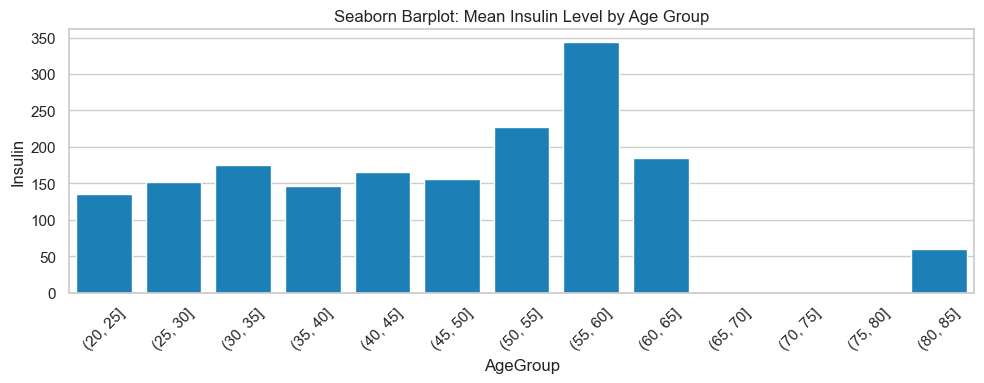

In [15]:
plt.figure(figsize=(10, 4))
sns.barplot(x='AgeGroup', y='Insulin', data=df[df['Insulin'] > 0], errorbar=None, color='#0288D1')
plt.title('Seaborn Barplot: Mean Insulin Level by Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Histplot with KDE: Glucose level distributions

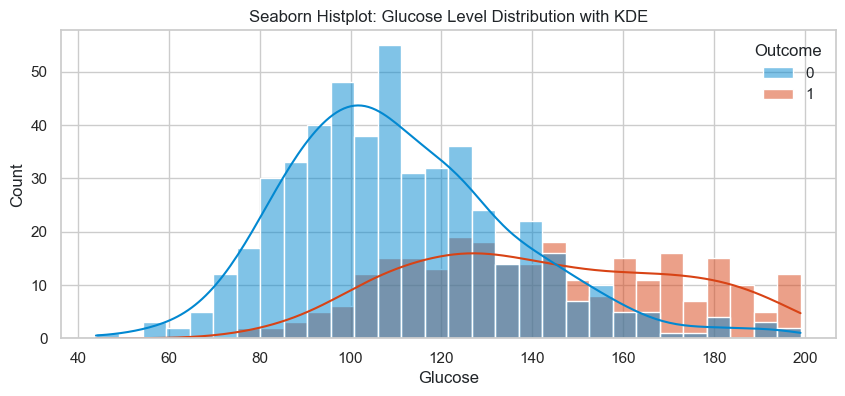

In [16]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df[df['Glucose'] > 0], x='Glucose', hue='Outcome', bins=30, kde=True, common_norm=False, palette=['#0288D1', '#D84315'])
plt.title('Seaborn Histplot: Glucose Level Distribution with KDE')
plt.show()

### 4. KDE Plot: Age Distribution comparing Outcome classes

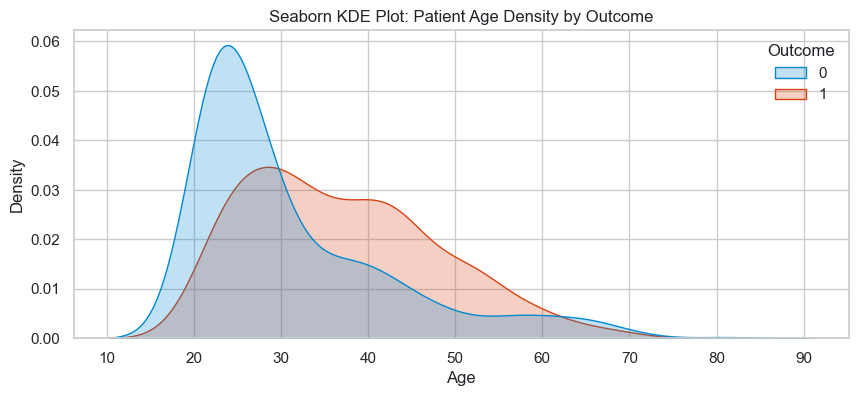

In [17]:
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df, x='Age', hue='Outcome', fill=True, common_norm=False, palette=['#0288D1', '#D84315'])
plt.title('Seaborn KDE Plot: Patient Age Density by Outcome')
plt.show()

### 5. Boxplot & Violinplot of primary clinical features (Glucose & BMI)
Let's compare Glucose and BMI distributions across outcomes.

C:\Users\user\AppData\Local\Temp\ipykernel_215864\2544948695.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df[df['Glucose'] > 0], ax=axes[0], palette=['#0288D1', '#D84315'])
C:\Users\user\AppData\Local\Temp\ipykernel_215864\2544948695.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y='BMI', data=df[df['BMI'] > 0], ax=axes[1], palette=['#0288D1', '#D84315'])


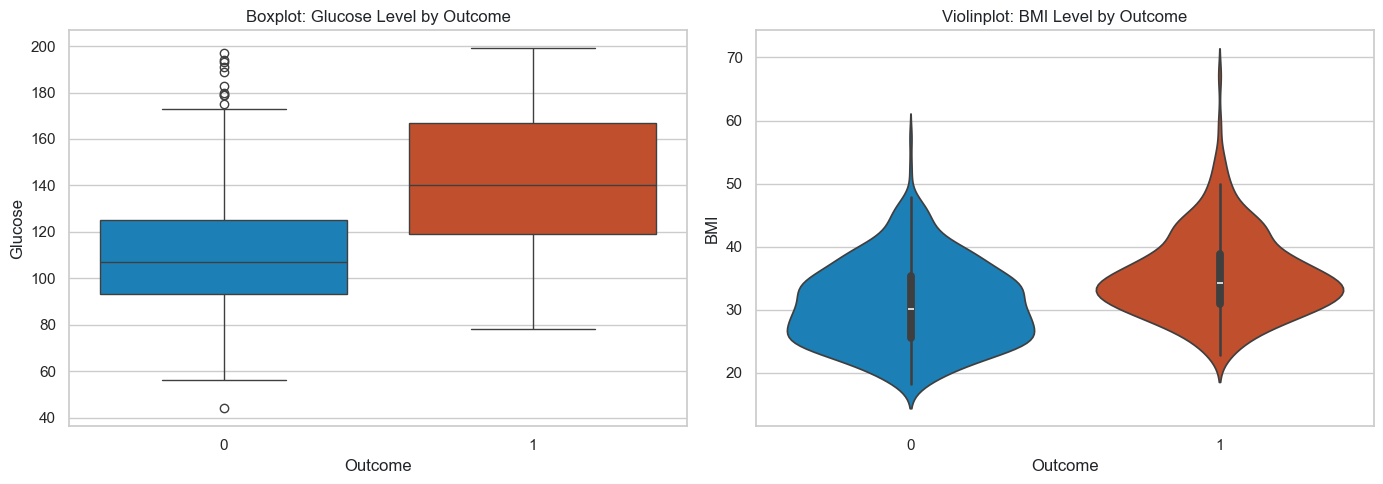

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot of Glucose
sns.boxplot(x='Outcome', y='Glucose', data=df[df['Glucose'] > 0], ax=axes[0], palette=['#0288D1', '#D84315'])
axes[0].set_title('Boxplot: Glucose Level by Outcome')

# Violinplot of BMI
sns.violinplot(x='Outcome', y='BMI', data=df[df['BMI'] > 0], ax=axes[1], palette=['#0288D1', '#D84315'])
axes[1].set_title('Violinplot: BMI Level by Outcome')

plt.tight_layout()
plt.show()

### 6. Stripplot: SkinThickness distribution scatter

C:\Users\user\AppData\Local\Temp\ipykernel_215864\942942358.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Outcome', y='SkinThickness', data=df[df['SkinThickness'] > 0], jitter=0.3, alpha=0.4, size=3, palette=['#0288D1', '#D84315'])


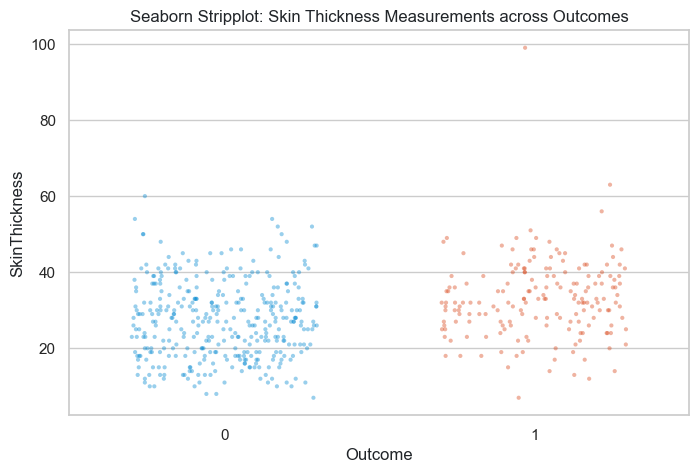

In [19]:
plt.figure(figsize=(8, 5))
sns.stripplot(x='Outcome', y='SkinThickness', data=df[df['SkinThickness'] > 0], jitter=0.3, alpha=0.4, size=3, palette=['#0288D1', '#D84315'])
plt.title('Seaborn Stripplot: Skin Thickness Measurements across Outcomes')
plt.show()

### 7. Jointplot: Visualizing correlation between Glucose and BMI
We draw a jointplot to show marginal distributions alongside the correlation scatter.

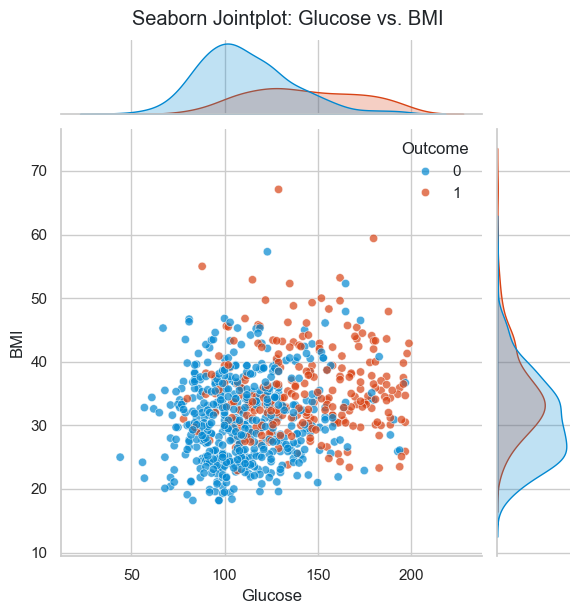

In [20]:
grid = sns.jointplot(x='Glucose', y='BMI', data=df[(df['Glucose'] > 0) & (df['BMI'] > 0)], hue='Outcome', palette=['#0288D1', '#D84315'], alpha=0.7, height=6)
grid.fig.suptitle('Seaborn Jointplot: Glucose vs. BMI', y=1.02)
plt.show()

### 8. Pairplot: Multi-variable interactions

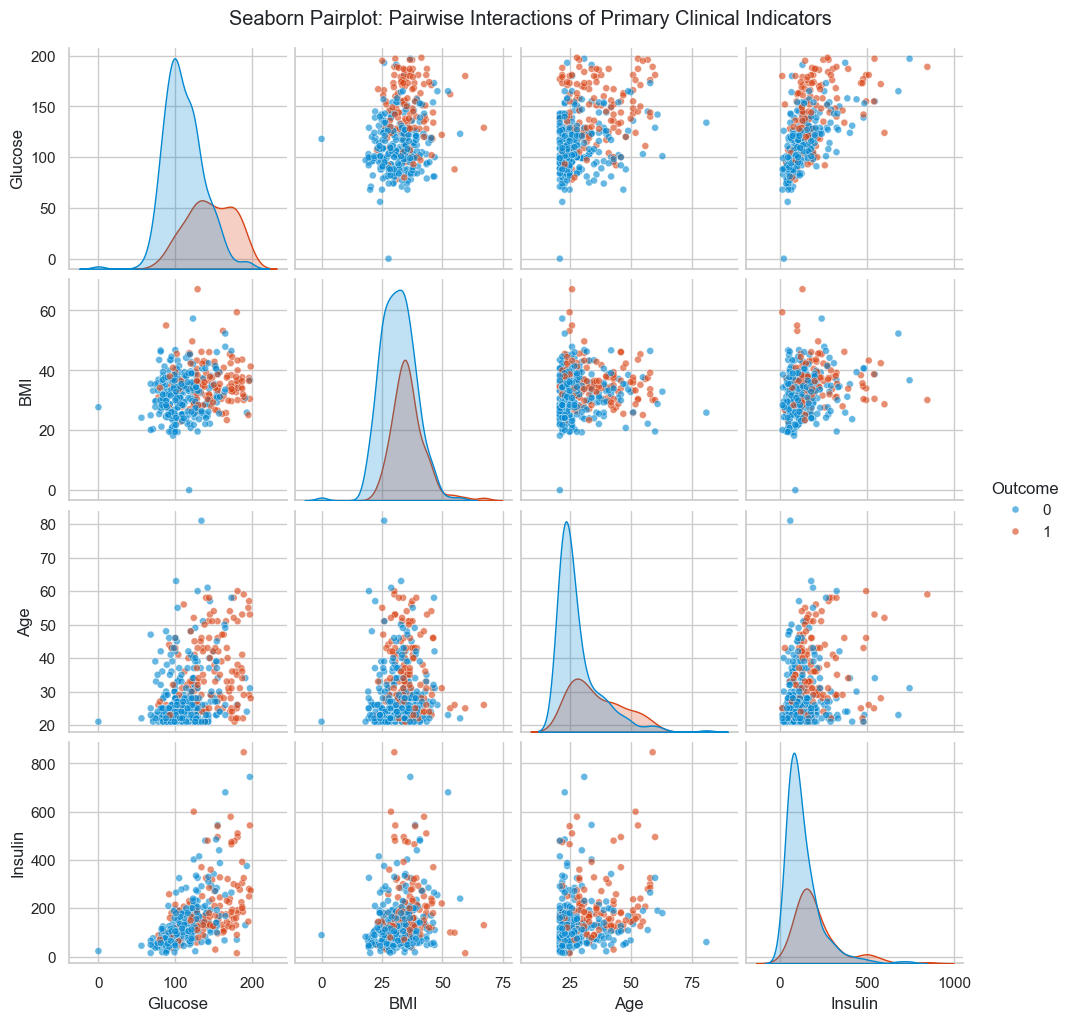

In [21]:
features_to_plot = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
df_pair = df[df['Insulin'] > 0][features_to_plot]
sns.pairplot(df_pair, hue='Outcome', palette=['#0288D1', '#D84315'], diag_kind='kde', plot_kws={'alpha':0.6, 's':25})
plt.suptitle('Seaborn Pairplot: Pairwise Interactions of Primary Clinical Indicators', y=1.02)
plt.show()

## Part 4: Data Leakage Protection & Train-Test Splits
To prevent **Data Leakage**, we partition our dataset into training and test sets *before* performing any imputation or scaling. 

First, we remove the hourly visual helper column (`AgeGroup`) and map invalid `0` values to `NaN` so our Scikit-Learn `SimpleImputer` can catch them cleanly during the pipeline.

In [22]:
from sklearn.model_selection import train_test_split

# Drop visual helper column and separate targets
X = df.drop(columns=['Outcome', 'AgeGroup'])
y = df['Outcome']

# Replace biologically impossible zeros with NaN
impossible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X[impossible_cols] = X[impossible_cols].replace(0, np.nan)

# Stratified Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Set Features Shape:", X_train.shape)
print("Testing Set Features Shape:", X_test.shape)
print("\nNull values present in training split after NaN replacement:")
print(X_train.isnull().sum())

Training Set Features Shape: (614, 8)
Testing Set Features Shape: (154, 8)

Null values present in training split after NaN replacement:
Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


## Part 5: Modular Preprocessing Pipeline
We build an pipeline utilizing `SimpleImputer` with a `'median'` strategy to impute missing NaNs safely, followed by a `StandardScaler` to normalize features.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Fit preprocessor strictly on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessed training features shape:", X_train_processed.shape)
print("Confirming zero null values remain:", np.isnan(X_train_processed).sum())

Preprocessed training features shape: (614, 8)
Confirming zero null values remain: 0


## Part 6: Model Building & Comparison
We train three baseline classification configurations: **Logistic Regression**, **Random Forest**, and **XGBoost**. 

To account for class imbalance, we adjust class weights inside the algorithms (`class_weight='balanced'` or `scale_pos_weight`).

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Logistic Regression with balanced weights
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_processed, y_train)

# 2. Random Forest Classifier with balanced weights
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_processed, y_train)

# 3. XGBoost Classifier with scaled weights
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
xgb.fit(X_train_processed, y_train)

print("Logistic Regression, Random Forest, and XGBoost models trained successfully!")

Logistic Regression, Random Forest, and XGBoost models trained successfully!


## Part 7: Model Evaluation & Diagnostics
We write a utility function to evaluate each model. In diagnostic models, we prioritize **Recall** (Sensitivity) because missing a diabetic patient (False Negative) has severe health consequences.

=== Logistic Regression (Weighted) ===
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

ROC-AUC Score: 0.8126



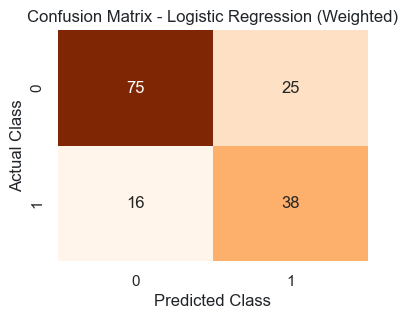

=== Random Forest (Weighted) ===
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       100
           1       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154

ROC-AUC Score: 0.8108



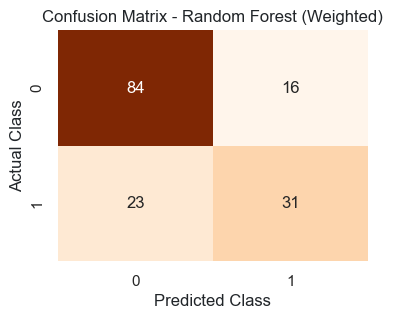

=== XGBoost (Weighted) ===
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

ROC-AUC Score: 0.8172



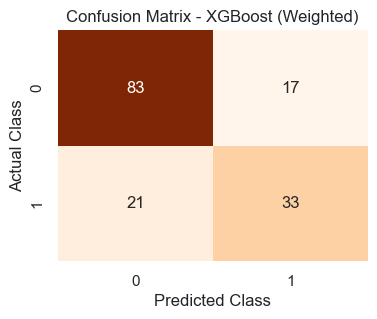

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"=== {title} ===")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}\n")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

evaluate_model(lr, X_test_processed, y_test, "Logistic Regression (Weighted)")
evaluate_model(rf, X_test_processed, y_test, "Random Forest (Weighted)")
evaluate_model(xgb, X_test_processed, y_test, "XGBoost (Weighted)")

## Part 8: Hyperparameter Tuning
We tune the parameters of our XGBoost model using `RandomizedSearchCV`, scoring specifically on `'recall'` or `'f1'` to optimize for positive diagnoses.

Best Hyperparameters Found: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.05}
=== Tuned XGBoost ===
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       100
           1       0.62      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154

ROC-AUC Score: 0.8194



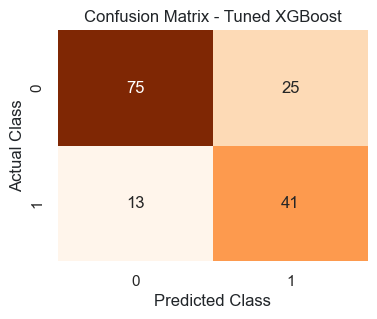

In [26]:
from sklearn.model_selection import RandomizedSearchCV

# Param grid
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=8,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_processed, y_train)
best_xgb = random_search.best_estimator_

print("Best Hyperparameters Found:", random_search.best_params_)
evaluate_model(best_xgb, X_test_processed, y_test, "Tuned XGBoost")

## Part 9: Serialization & Export
Finally, we bundle the preprocessing steps and the tuned model into a single pipeline, serialize it, and export it using `joblib` so it can be deployed on servers (like a Streamlit Cloud app).

In [27]:
import joblib

# Create full inference pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_xgb)
])

# Export files
joblib.dump(full_pipeline, 'best_diabetes_model.pkl')
print("Full model pipeline successfully saved as best_diabetes_model.pkl!")

Full model pipeline successfully saved as best_diabetes_model.pkl!
